In [2]:
import numpy as np
import matplotlib.pyplot as plt
from math import factorial


#define a_n, b_n multipole components 
a_n = [5,3,1,7]#don't use exactly 0 because downstream we will compute relative errors, and 0 would cause division by zero
b_n = [1,4,3,2]
#define x axis
x = np.linspace(-1, 1, 101)

The field in the midplane can then be computed using 

$B_x(x, y=0, s) = \sum_{n=1}^\infty a_n(s) \frac{x^{n-1}}{(n-1)!} $

and 


$B_y(x, y=0, s) = \sum_{n=1}^\infty b_n(s) \frac{x^{n-1}}{(n-1)!}$

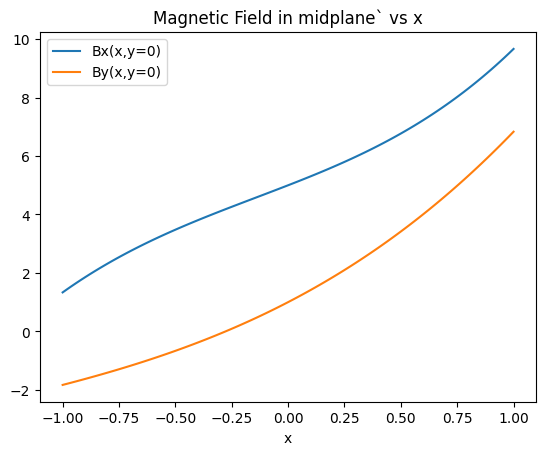

In [3]:
def BxofxfromMultipole(x, a_n, b_n): 
    Bx = np.zeros(len(x))
    for i in range(len(x)):
        for n in range(1,len(a_n)+1):
            Bx[i] += a_n[n-1]*x[i]**(n-1) / factorial(n-1)
    return Bx
def ByofxfromMultipole(x, a_n, b_n):
    By = np.zeros(len(x))
    for i in range(len(x)):
        for n in range(1,len(b_n)+1):
            By[i] += b_n[n-1]*x[i]**(n-1) / factorial(n-1)
    return By
Bx=BxofxfromMultipole(x, a_n, b_n) 
By=ByofxfromMultipole(x, a_n, b_n)
plt.plot(x, Bx)
plt.plot(x, By)
plt.xlabel('x')
plt.legend(['Bx(x,y=0)', 'By(x,y=0)'])
plt.title('Magnetic Field in midplane` vs x')           
plt.show()

Now we can go back to the multipole components using 

$a_{n}(s) = \left. \partial^{n-1}_x B_x(x,y,s) \right|_{x=y=0}$

and

$ b_{n}(s) = \left. \partial^{n-1}_x B_y(x,y,s) \right|_{x=y=0} $

In [4]:
def derivativesFromField(x, B, max_order):
    dBvector=np.zeros((max_order, len(B)))
    dBvector[0,:]=B
    for i in range(1,max_order):
        dBvector[i,:]=np.gradient(dBvector[i-1,:], x) #compute higher order derivatives recursively
    return dBvector
max_order = len(a_n)+1
idx_zero = np.argmin(np.abs(x))

dBxvector=derivativesFromField(x, Bx, max_order)
dByvector=derivativesFromField(x, By, max_order)
print("dBxvectorat x=0:", dBxvector[:, idx_zero])
print("dByvectorat x=0:", dByvector[:, idx_zero])

a_nnew=np.zeros(len(a_n))
b_nnew=np.zeros(len(b_n))
a_nnew[:]=dBxvector[:len(a_n),idx_zero]
b_nnew[:]=dByvector[:len(b_n),idx_zero]
print("Original a_n:", a_n)
print("Recovered a_n:", a_nnew)
print("Original b_n:", b_n)
print("Recovered b_n:", b_nnew)



dBxvectorat x=0: [5.00000000e+00 3.00046667e+00 1.00000000e+00 7.00000000e+00
 1.77635684e-11]
dByvectorat x=0: [ 1.00000000e+00  4.00013333e+00  3.00000000e+00  2.00000000e+00
 -1.32871492e-10]
Original a_n: [5, 3, 1, 7]
Recovered a_n: [5.         3.00046667 1.         7.        ]
Original b_n: [1, 4, 3, 2]
Recovered b_n: [1.         4.00013333 3.         2.        ]


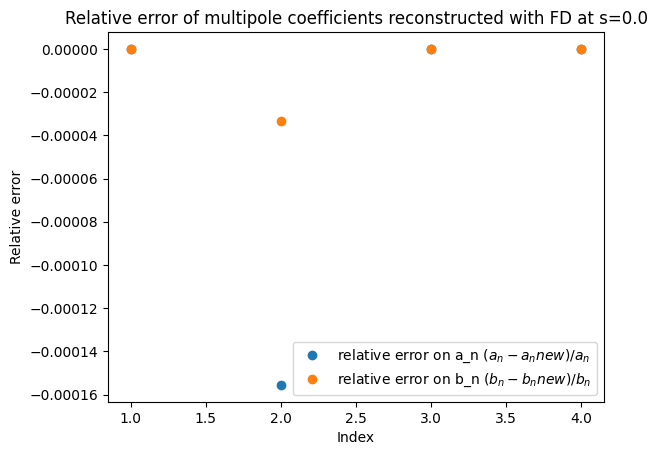

In [7]:
plt.plot(range(1, len(a_n)+1), (a_n-a_nnew)/a_n, 'o', label='relative error on a_n $(a_n - a_nnew)/a_n$')
plt.xlabel('Index')
plt.ylabel('Relative error')
plt.title('Relative error of multipole coefficients reconstructed with FD at s=0.0')
plt.plot(range(1, len(b_n)+1), (b_n-b_nnew)/b_n, 'o', label='relative error on b_n $(b_n - b_nnew)/b_n$')
plt.legend()
plt.show()